### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [2]:
tf.__version__

'1.14.0'

### Collect Data

In [0]:
import keras

In [0]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.utils import np_utils
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

In [0]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [8]:
print(testY[0:5])

[9 2 1 1 6]


In [23]:
# Shapes of training set
print("Training set (images) shape: {shape}".format(shape=trainX.shape))
print("Training set (labels) shape: {shape}".format(shape=trainY.shape))

Training set (images) shape: (60000, 28, 28)
Training set (labels) shape: (60000, 10)


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [14]:
trainY[0:5]

array([9, 0, 0, 3, 0], dtype=uint8)

In [0]:
#Encoding the output class label (One-Hot Encoding)
trainY=np_utils.to_categorical(trainY)
testY=np_utils.to_categorical(testY)

In [20]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

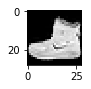

Label for image =  9


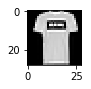

Label for image =  0


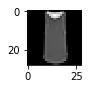

Label for image =  0


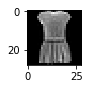

Label for image =  3


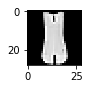

Label for image =  0


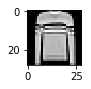

Label for image =  2


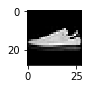

Label for image =  7


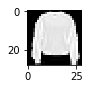

Label for image =  2


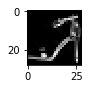

Label for image =  5


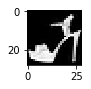

Label for image =  5


In [160]:
for i in range (10):
  plt.subplots(figsize=(1, 1))
  plt.imshow(trainX[i,:,:],cmap='gray')
  plt.grid(False)
  plt.show()
  # Get corresponding integer label from one-hot encoded data
  label = np.where(trainY[i] == 1)[0][0]
  print("Label for image = ", label)

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [0]:
trainX=trainX.reshape(trainX.shape[0],28,28,1).astype('float32')
testX=testX.reshape(testX.shape[0],28,28,1).astype('float32')

In [0]:
model_i = tf.keras.Sequential()


#define the input shape in the first layer of the neural network
model_i.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2, padding='same', activation='relu', input_shape=(28,28,1))) 
model_i.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model_i.add(tf.keras.layers.Dropout(0.3))

model_i.add(tf.keras.layers.Flatten())

model_i.add(tf.keras.layers.Dense(128, activation='relu'))
model_i.add(tf.keras.layers.Dense(10, activation='softmax'))


In [0]:
model_i.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

### Execute the model using model.fit()

In [139]:
model_i.fit(trainX,trainY,batch_size=200,epochs=5,verbose=1,validation_data=(testX, testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 60s 992us/sample - loss: 2.0529 - acc: 0.7545 - val_loss: 0.4148 - val_acc: 0.8554
Epoch 2/5
60000/60000 [==============================] - 59s 983us/sample - loss: 0.4297 - acc: 0.8464 - val_loss: 0.3844 - val_acc: 0.8611
Epoch 3/5
60000/60000 [==============================] - 59s 984us/sample - loss: 0.3913 - acc: 0.8592 - val_loss: 0.3498 - val_acc: 0.8761
Epoch 4/5
60000/60000 [==============================] - 59s 977us/sample - loss: 0.3677 - acc: 0.8668 - val_loss: 0.3415 - val_acc: 0.8777
Epoch 5/5
60000/60000 [==============================] - 59s 983us/sample - loss: 0.3439 - acc: 0.8755 - val_loss: 0.3260 - val_acc: 0.8826


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [0]:
# import BatchNormalization
from keras.layers import BatchNormalization

model_n = tf.keras.Sequential()

#define the input shape in the first layer of the neural network
model_n.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2, padding='same', activation='relu', input_shape=(28,28,1))) 
model_n.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model_n.add(tf.keras.layers.Dropout(0.3))

model_n.add(tf.keras.layers.Flatten())

model_n.add(tf.keras.layers.Dense(128, activation='relu'))
model_n.add(tf.keras.layers.BatchNormalization())

model_n.add(tf.keras.layers.Dense(10, activation='softmax'))

### Execute the model

In [0]:
model_n.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [125]:
model_n.fit(trainX,trainY,batch_size=200,epochs=5,verbose=1,validation_data=(testX, testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 65s 1ms/sample - loss: 0.6269 - acc: 0.7805 - val_loss: 0.4627 - val_acc: 0.8385
Epoch 2/5
60000/60000 [==============================] - 63s 1ms/sample - loss: 0.4403 - acc: 0.8451 - val_loss: 0.4030 - val_acc: 0.8606
Epoch 3/5
60000/60000 [==============================] - 63s 1ms/sample - loss: 0.3881 - acc: 0.8637 - val_loss: 0.3765 - val_acc: 0.8643
Epoch 4/5
60000/60000 [==============================] - 63s 1ms/sample - loss: 0.3568 - acc: 0.8750 - val_loss: 0.3479 - val_acc: 0.8753
Epoch 5/5
60000/60000 [==============================] - 62s 1ms/sample - loss: 0.3353 - acc: 0.8818 - val_loss: 0.3253 - val_acc: 0.8827


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras.optimizers import SGD

sgd = tf.keras.optimizers.SGD(lr=0.001)
model_n.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [129]:
model_n.fit(trainX,trainY,batch_size=200,epochs=5,verbose=1,validation_data=(testX, testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 63s 1ms/sample - loss: 0.3160 - acc: 0.8888 - val_loss: 0.3194 - val_acc: 0.8831
Epoch 2/5
60000/60000 [==============================] - 63s 1ms/sample - loss: 0.3140 - acc: 0.8894 - val_loss: 0.3166 - val_acc: 0.8849
Epoch 3/5
60000/60000 [==============================] - 62s 1ms/sample - loss: 0.3127 - acc: 0.8894 - val_loss: 0.3158 - val_acc: 0.8852
Epoch 4/5
60000/60000 [==============================] - 63s 1ms/sample - loss: 0.3097 - acc: 0.8900 - val_loss: 0.3150 - val_acc: 0.8833
Epoch 5/5
60000/60000 [==============================] - 62s 1ms/sample - loss: 0.3104 - acc: 0.8902 - val_loss: 0.3130 - val_acc: 0.8856


### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
model_f = tf.keras.Sequential()

#define the input shape in the first layer of the neural network
model_f.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2, padding='same', activation='sigmoid', input_shape=(28,28,1))) 
model_f.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model_f.add(tf.keras.layers.Dropout(0.3))

model_f.add(tf.keras.layers.Flatten())

# add input layer with 100 neurons
model_f.add(tf.keras.layers.Dense(100, activation='sigmoid'))

# add first hidden layer with 100 neurons
model_f.add(tf.keras.layers.Dense(100, activation='sigmoid'))
model_f.add(tf.keras.layers.BatchNormalization())

# add output layer with 100 neurons
model_f.add(tf.keras.layers.Dense(10, activation='softmax'))


In [0]:
sgd = tf.keras.optimizers.SGD(lr=0.03)
model_f.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

## Review model

In [131]:
# Take a look at the model summary
model_f.summary()

Model: "sequential_30"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_29 (Conv2D)           (None, 28, 28, 64)        320       
_________________________________________________________________
max_pooling2d_28 (MaxPooling (None, 14, 14, 64)        0         
_________________________________________________________________
dropout_31 (Dropout)         (None, 14, 14, 64)        0         
_________________________________________________________________
flatten_25 (Flatten)         (None, 12544)             0         
_________________________________________________________________
dense_39 (Dense)             (None, 100)               1254500   
_________________________________________________________________
dense_40 (Dense)             (None, 100)               10100     
_________________________________________________________________
batch_normalization_7 (Batch (None, 100)             

### Run the model

In [133]:
model_f.fit(trainX,trainY,batch_size=200,epochs=5,verbose=1,validation_data=(testX, testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 61s 1ms/sample - loss: 0.5267 - acc: 0.8150 - val_loss: 1.0554 - val_acc: 0.8458
Epoch 2/5
60000/60000 [==============================] - 61s 1ms/sample - loss: 0.3826 - acc: 0.8637 - val_loss: 0.3752 - val_acc: 0.8733
Epoch 3/5
60000/60000 [==============================] - 61s 1ms/sample - loss: 0.3458 - acc: 0.8758 - val_loss: 0.3460 - val_acc: 0.8759
Epoch 4/5
60000/60000 [==============================] - 61s 1ms/sample - loss: 0.3217 - acc: 0.8845 - val_loss: 0.3260 - val_acc: 0.8857
Epoch 5/5
60000/60000 [==============================] - 61s 1ms/sample - loss: 0.3097 - acc: 0.8871 - val_loss: 0.2984 - val_acc: 0.8927


In [142]:
# Evaluate the model on test set
score_i = model_i.evaluate(testX, testY, verbose=0)
score_n = model_n.evaluate(testX, testY, verbose=0)
score_f = model_f.evaluate(testX, testY, verbose=0)
# Print test accuracy
print('\n', 'Test accuracy for Initial Model :', score_i[1])
print('\n', 'Test accuracy for Normalized Model :', score_n[1])
print('\n', 'Test accuracy for Final Model :', score_f[1])


 Test accuracy for Initial Model : 0.8826

 Test accuracy for Normalized Model : 0.8856

 Test accuracy for Final Model : 0.8927
